# Mount Google Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install unrar

Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
rar_path = '/content/drive/MyDrive/NonOct.rar'
extract_path = '/content/dataset'

import os
os.makedirs(extract_path, exist_ok=True)

!unrar x "{rar_path}" "{extract_path}/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/NonOct.rar

Creating    /content/dataset/NonOct                                   OK
Creating    /content/dataset/NonOct/test                              OK
Creating    /content/dataset/NonOct/test/non_oct                      OK
Extracting  /content/dataset/NonOct/test/non_oct/000002 (4).png            0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000002 (6).png            0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000002.png                0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000003 (3).png            0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000003 (4).png            0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000003.png                0%  OK 
Extracting  /content/dataset/NonOct/test/non_oct/000004 (4).png            0%  OK 
Extracting

# Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Dataset Directory Setup and Validation

In [ ]:
base_dir = '/content/dataset/NonOct/'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

print("Training directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

def count_images(directory):
    classes = ['oct_scan', 'non_oct']
    for cls in classes:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            print(f"{cls} images in {directory}: {len(os.listdir(path))}")
        else:
            print(f"Path {path} does not exist")

count_images(train_dir)
count_images(test_dir)

Training directory exists: True
Test directory exists: True
oct_scan images in /content/dataset/NonOct/train: 804
non_oct images in /content/dataset/NonOct/train: 703
oct_scan images in /content/dataset/NonOct/test: 251
non_oct images in /content/dataset/NonOct/test: 259


# Image Data Preprocessing and Augmentation

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Only rescaling for test
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_oct', 'oct_scan']  # non_oct=0, oct=1
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_oct', 'oct_scan'],  # non_oct=0, oct=1
    shuffle=False
)

Found 1507 images belonging to 2 classes.
Found 510 images belonging to 2 classes.


# Model Architecture Definition (Transfer Learning with MobileNetV2)

In [ ]:
def create_model():
    # Use transfer learning with a pre-trained model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

model = create_model()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Model Training with Callbacks and Fine-tuning

In [ ]:
# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

steps_per_epoch = train_generator.samples // BATCH_SIZE
test_steps = test_generator.samples // BATCH_SIZE

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=15,
    validation_data=test_generator,
    validation_steps=test_steps,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 876ms/step - accuracy: 0.9554 - loss: 0.0997 - val_accuracy: 0.9979 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 2/15
 1/47 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 1.0000 - loss: 8.7852e-04

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 1.0000 - loss: 8.7852e-04 - val_accuracy: 0.9979 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 477ms/step - accuracy: 1.0000 - loss: 7.9617e-04 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 1.0000 - loss: 2.4636e-04 - val_accuracy: 0.9979 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 547ms/step - accuracy: 1.0000 - loss: 8.9122e-04 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 1.0000 - loss: 2.1164e-05 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 889ms/step - accuracy: 0.9995 - loss: 7.7084e-04 - val_accuracy: 1.0000 - val_loss: 6.7668e-05 - learning_rate: 0.0010
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 -

In [ ]:
# Unfreeze the base model for fine-tuning
base_model = model.layers[0]
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_fine = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=test_generator,
    validation_steps=test_steps,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 65s 874ms/step - accuracy: 0.8760 - loss: 0.3179 - val_accuracy: 1.0000 - val_loss: 3.3525e-06 - learning_rate: 1.0000e-05
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 3.3066e-06 - learning_rate: 1.0000e-05
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 557ms/step - accuracy: 0.9835 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 2.4550e-06 - learning_rate: 1.0000e-05
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 2.4392e-06 - learning_rate: 1.0000e-05
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 497ms/step - accuracy: 0.9833 - loss: 0.0413 - val_accuracy: 1.0000 - val_loss: 2.3466e-06 - learning_rate: 2.0000e-06
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 2.3445e-06 - learning_rate: 2.0000e-06
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 41

# Model Evaluation and Performance Metrics

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(cm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 1.0000 - loss: 2.5161e-06
Test Accuracy: 100.00%
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 457ms/step
Classification Report:
              precision    recall  f1-score   support

     non_oct       1.00      1.00      1.00       259
    oct_scan       1.00      1.00      1.00       251

    accuracy                           1.00       510
   macro avg       1.00      1.00      1.00       510
weighted avg       1.00      1.00      1.00       510

Confusion Matrix:
[[259   0]
 [  0 251]]


# Confusion Matrix

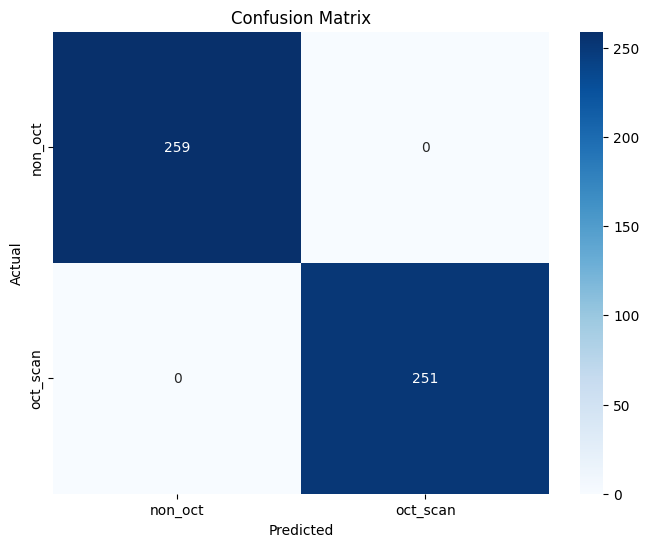

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Model Saving and OCT Image Prediction Function

In [ ]:
model.save('/content/drive/MyDrive/oct_detector_model.h5')
print("Model saved successfully!")

Model saved successfully!


# Sample Prediction Test and Validation

In [ ]:
def predict_oct_image(image_path, model, threshold=0.5):

    img = keras.preprocessing.image.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0


    prediction = model.predict(img_array)[0][0]
    is_oct = prediction > threshold

    return is_oct, float(prediction)

sample_image_path = "/content/dataset/NonOct/test/oct_scan/CNV-103044-105.jpeg"
if os.path.exists(sample_image_path):
    is_oct, confidence = predict_oct_image(sample_image_path, model)
    if is_oct:
        print(f"This appears to be an OCT scan (confidence: {confidence:.2%})")
    else:
        print(f"Warning: This does not appear to be an OCT scan (confidence: {confidence:.2%})")
else:
    print("Sample image not found. Please update the path.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
This appears to be an OCT scan (confidence: 100.00%)
